# Multivariable Logistic Regression (ESBL)

This notebook explores predictors of ESBL status and checks model assumptions before fitting a multivariable logistic regression model.


# Notebook run instructions

This notebook should be run in the SDE after importing the cleaned `analysis_df`.

## Intended order

1. Load packages, project paths, and `analysis_df`.
2. Restrict to surgical infection episodes using `surgery_before_infection == 1`.
3. Keep required modelling columns, including:
   - `subject_id`
   - `sample_collection_date`
   - outcome: `esbl_status`
   - all candidate predictors.
4. Recode prophylaxis groups.
5. Remove unknown/missing categories as pre-specified.
6. Check cohort size, ESBL/non-ESBL counts, and repeated infection episodes per patient.
7. Encode categorical predictors using dummy variables with `prefix_sep="__"`.
8. Drop one reference category per categorical variable.
9. Check EPV, missingness, sparse categories, correlation, and VIF.
10. Fit main multivariable logistic regression on the full analysis cohort.
11. Report adjusted ORs, 95% CIs, p-values, and test-set AUC.
12. Plot ROC curve using test-set predictions only.
13. Run first-episode-only sensitivity analysis.
14. Compare main LR vs first-episode sensitivity ORs.
15. Run GEE clustered by `subject_id` as an additional sensitivity analysis.
16. Compare main LR vs GEE ORs.
17. Run exploratory stratified models by TFC and sample site only where there are sufficient ESBL and non-ESBL events.
18. Optionally produce calibration curve and confusion matrix if discussing prediction performance.
19. Export final tables:
   - main adjusted OR table
   - sensitivity comparison table
   - GEE comparison table
   - stratified model summaries
   - missingness/diagnostic outputs.

## Main interpretation rules

The primary result is the multivariable logistic regression adjusted OR table.

The test-set AUC describes discrimination/predictive performance, not causal association.

The full-data AUC should not be reported as the main AUC because it is optimistic.

Sensitivity analyses are used to check whether conclusions change when repeated patient episodes are handled differently.

Stratified analyses should be interpreted as exploratory, especially where event numbers are small.

P-values should not be interpreted alone; effect size, confidence intervals, clinical plausibility, and robustness across sensitivity analyses should also be considered.

## 1) Setup and Data Load


In [4]:
import numpy as np
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy.builtins import Q 
import sklearn as sk
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent     
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from utils import data_cleaning_tools as dct
cfg_path="../configs/config.yaml"
cfg = dct.load_config(cfg_path)

df_path = PROJECT_ROOT / 'data' / 'interim' / 'analysis_df.csv'
analysis_df = pd.read_csv(df_path)

In [ ]:
analysis_df = analysis_df[analysis_df['surgery_before_infection'] == 1]

analysis_df = analysis_df.drop(columns = ['n_samples', 'surgery_before_infection', 'n_sites'])

to_keep = [
    "subject_id",
    "sample_collection_date",
    "asthma",
    "colonisation",
    "copd",
    "crp",
    "days_from_admission_to_first_culture",
    "ethnicity_desc",
    "gender",
    "hospital_exposure_90d",
    "organism_bug",
    "past_abx",
    "prophylaxis_class",
    "prophylaxis_group",
    "site",
    "tfc",
    "type2_diabetes",
    "esbl_status"
]

analysis_df = analysis_df[to_keep]

In [17]:
def regroup_prophylaxis(x):
    if pd.isna(x):
        return pd.NA
    
    x = x.lower().strip()

    if "cefuroxime" in x and "metronidazole" in x:
        return "cefuroxime + metronidazole"
    
    if "co-amoxiclav" in x:
        return "co-amoxiclav-based"
    
    if "glycopeptide" in x or "teicoplanin" in x or "vancomycin" in x:
        return "glycopeptide-based"
    
    if "aminoglycoside" in x or "gentamicin" in x:
        return "aminoglycoside-based"
    
    if "clindamycin" in x:
        return "clindamycin-based"
    
    if "metronidazole" in x:
        return "metronidazole-only/+other"
    
    if "cefuroxime" in x:
        return "cefuroxime-only/+other"
    
    if "piperacillin-tazobactam" in x:
        return "broad-spectrum beta-lactam"
    
    return "other"

analysis_df["prophylaxis_group"] = (
    analysis_df["prophylaxis_group"]
    .apply(regroup_prophylaxis))

analysis_df = dct.remove_unknowns(analysis_df)

In [18]:
for col in analysis_df.columns:
    print(f"{col} unique values: {analysis_df[col].nunique()}")

asthma unique values: 2
colonisation unique values: 2
copd unique values: 2
crp unique values: 1228
days_from_admission_to_first_culture unique values: 113
ethnicity_desc unique values: 5
gender unique values: 2
hospital_exposure_90d unique values: 2
organism_bug unique values: 4
past_abx unique values: 2
prophylaxis_group unique values: 7
site unique values: 7
tfc unique values: 10
type2_diabetes unique values: 2
esbl_status unique values: 2


## Working Notes and TODO

- collinearity and multicollinearity (variables highly correalted) is bad bc model can't tell which variable is responsible for the changes in outcome 
    - coefficients become unstable + very larger CIs

- dummy variables - binary encodings of categorical variables
    - drop one category so you don't get a perfect linear relationship = one variable cannot be exactly predicted from others 

- what is EPV? (number of events/ number of variables)
     - needs to be >10


**Final intuitions**:

- Dummy variables → allow categories into regression
- Dropping one → avoids mathematical impossibility
- VIF → detects redundancy
- EPV → protects against overfitting
- AUROC → evaluates prediction, not causality

In [ ]:
def run_univariable_lr(
    df,
    predictors,
    outcome_col="esbl_status",
    categorical_cols=None,
    reference_categories=None
):
    """
    Run univariable logistic regression for each predictor separately.

    Returns:
        - summary_df: one row per predictor term
        - models: dictionary of fitted models
    """

    import pandas as pd
    import numpy as np
    import statsmodels.api as sm

    if categorical_cols is None:
        categorical_cols = [
            "ethnicity_desc",
            "organism_bug",
            "prophylaxis_group",
            "site",
            "tfc"
        ]

    if reference_categories is None:
        reference_categories = {
            "organism_bug": "escherichia coli",
            "site": "blood",
            "ethnicity_desc": "white",
            "prophylaxis_group": "cefuroxime + metronidazole",
            "tfc": "general_surgery"
        }

    results = []
    models = {}

    # Outcome
    y_full = df[outcome_col]

    if y_full.dtype == "object":
        y_full = y_full.map({"ESBL": 1, "non-ESBL": 0})

    for predictor in predictors:

        try:

            temp_df = df[[predictor, outcome_col]].copy()

            # Drop missing
            temp_df = temp_df.dropna()

            y = temp_df[outcome_col]

            if y.dtype == "object":
                y = y.map({"ESBL": 1, "non-ESBL": 0})

            X = temp_df[[predictor]].copy()

            # Handle categorical predictors
            if predictor in categorical_cols:

                X = pd.get_dummies(
                    X,
                    columns=[predictor],
                    prefix_sep="__",
                    drop_first=False,
                    dtype=int
                )

                # Drop reference category
                if predictor in reference_categories:
                    ref = reference_categories[predictor]
                    X = X.drop(
                        columns=f"{predictor}__{ref}",
                        errors="ignore"
                    )

            # Convert to numeric
            X = X.apply(pd.to_numeric, errors="coerce")

            # Remove zero-variance cols
            X = X.loc[:, X.nunique() > 1]

            # Add intercept
            X = sm.add_constant(X, has_constant="add")

            # Fit model
            model = sm.Logit(y, X).fit(disp=False)

            models[predictor] = model

            conf = model.conf_int()

            for term in model.params.index:

                # Skip intercept row
                if term == "const":
                    continue

                results.append({
                    "predictor": predictor,
                    "term": term,
                    "OR": np.exp(model.params[term]),
                    "CI_lower": np.exp(conf.loc[term, 0]),
                    "CI_upper": np.exp(conf.loc[term, 1]),
                    "p_value": model.pvalues[term],
                    "n": len(temp_df),
                    "events": int(y.sum())
                })

        except Exception as e:

            results.append({
                "predictor": predictor,
                "term": "MODEL_FAILED",
                "OR": np.nan,
                "CI_lower": np.nan,
                "CI_upper": np.nan,
                "p_value": np.nan,
                "n": len(temp_df),
                "events": int(y.sum()) if "y" in locals() else np.nan,
                "error": str(e)
            })

    summary_df = pd.DataFrame(results)

    return summary_df, models

In [ ]:
predictors = [
    "age",
    "gender",
    "ethnicity_desc",
    "site",
    "tfc",
    "organism_bug",
    "prophylaxis_group"
]

uni_results, uni_models = run_univariable_lr(
    analysis_df,
    predictors=predictors
)

uni_results.sort_values("p_value").head(20)

## 2) Feature Engineering and EPV Check

Create dummy variables for categorical predictors and calculate events-per-variable (EPV) to gauge model stability.


In [24]:
analysis_df = analysis_df.drop(columns = 'prophylaxis_class',  errors="ignore")

In [ ]:
categorical_cols = ['ethnicity_desc', 'organism_bug', 'prophylaxis_group', 'site', 'tfc']

reference_categories = {
    'organism_bug': 'escherichia coli',
    'site': 'blood',
    'ethnicity_desc': 'white',
    'prophylaxis_group': 'cefuroxime + metronidazole',
    'tfc': 'general_surgery'
}

X = analysis_df.drop(columns=["esbl_status"])
y = analysis_df["esbl_status"]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False,
    prefix_sep="__",
    dtype=int
)

for col, ref in reference_categories.items():
    X_encoded = X_encoded.drop(columns=f"{col}__{ref}", errors="ignore")

multi_lr_df = X_encoded.copy()
multi_lr_df["esbl_status"] = y.map({"ESBL": 1, "non-ESBL": 0}) if y.dtype == "object" else y
    
n_predictors = multi_lr_df.drop(columns=["esbl_status"]).shape[1]
epv = multi_lr_df["esbl_status"].sum() / n_predictors
print(f"Events per variable (EPV): {epv:.2f}")

Events per variable (EPV): 19.45


In [36]:
multi_lr_df['crp'] = pd.to_numeric(multi_lr_df['crp'], errors = 'coerce')

In [44]:
multi_lr_df['gender'] = multi_lr_df['gender'].map({2: 1, 1: 0})

## 3) VIF and Correlation Screen for Multicollinearity

Visualize the correlation matrix to identify highly correlated predictors before model fitting.

- use Pearson's corrrelation coefficient to screen for collinearity
- VIF - variance inflation factor 


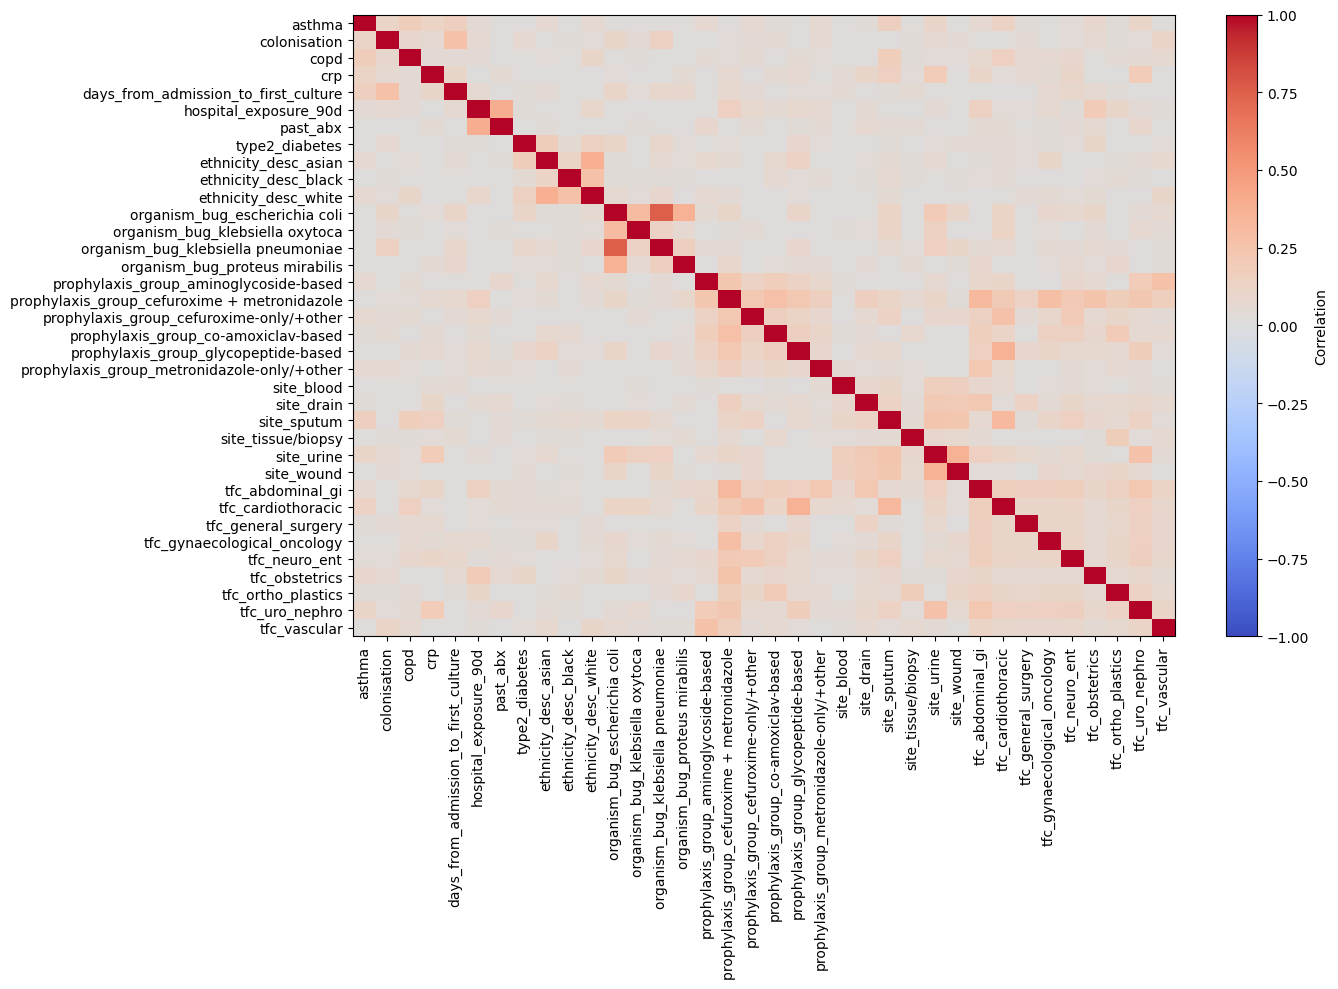

In [45]:
# Define a threshold for the absolute value of correlation
threshold = 0.15

# Select predictors only (exclude outcome) using column-safe indexing
predictor_df = multi_lr_df.drop(columns=['esbl_status'], errors='ignore')

# Correlation among predictors
corr_matrix = predictor_df.corr().abs()

# Keep variables that have at least one correlation above threshold (excluding self-correlation)
relevant_vars = corr_matrix.columns[(corr_matrix > threshold).sum() > 1]

# Apply the threshold to the correlation matrix
filtered_corr = corr_matrix.loc[relevant_vars, relevant_vars]

plt.figure(figsize=(14, 10))
plt.imshow(filtered_corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(filtered_corr.columns)), filtered_corr.columns, rotation=90)
plt.yticks(range(len(filtered_corr.index)), filtered_corr.index)
plt.tight_layout()
plt.show()

In [46]:
predictor_df

,asthma,colonisation,copd,crp,days_from_admission_to_first_culture,gender,hospital_exposure_90d,past_abx,type2_diabetes,ethnicity_desc_asian,...,tfc_abdominal_gi,tfc_cardiothoracic,tfc_general_surgery,tfc_gynaecological_oncology,tfc_gynaecology,tfc_neuro_ent,tfc_obstetrics,tfc_ortho_plastics,tfc_uro_nephro,tfc_vascular
0,0,0,0,50.9,14,0.0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,201.4,18,0.0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,1.0,15,NaN,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,0,248.8,5,NaN,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5,1,1,0,20.1,61,0.0,1,1,0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2199,0,0,0,NaN,14,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2200,0,0,0,NaN,14,NaN,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2201,1,1,1,260.2,5,NaN,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2202,0,0,1,180.9,5,NaN,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [11]:
# Example predictor matrix--
X = multi_lr_df.copy()
X = X.drop(columns=['esbl_status'])

# Convert boolean columns to integers
bool_cols = X.dtypes[X.dtypes == 'bool'].index
X[bool_cols] = X[bool_cols].astype(int)

# Drop rows with NaN values
X = X.dropna()

# Add constant
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df['variable'] = X.columns
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df = vif_df.sort_values(by="VIF", ascending=False)

print(vif_df[vif_df['VIF'] > 5])

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in double_scalars
  return 1 - self.ssr/self.centered_tss
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


                              variable        VIF
18      organism_bug_proteus mirabilis        inf
15       organism_bug_escherichia coli        inf
17  organism_bug_klebsiella pneumoniae        inf
16     organism_bug_klebsiella oxytoca        inf
35                    tfc_abdominal_gi  13.113900
43                      tfc_uro_nephro   9.647763
36                  tfc_cardiothoracic   8.878225
38         tfc_gynaecological_oncology   8.112320
40                       tfc_neuro_ent   8.054148
37                 tfc_general_surgery   7.437993
44                        tfc_vascular   6.039701
42                  tfc_ortho_plastics   5.650705


## 5) Modeling and Diagnostics 

Fit the logistic regression model here and report: odds ratios, confidence intervals, goodness-of-fit, and discrimination metrics.


In [12]:
df_model = multi_lr_df.copy()
df_model.columns = df_model.columns.str.replace(" ", "_")
df_model = df_model.dropna()


X = df_model.drop(columns=["esbl_status"])
y = df_model["esbl_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:

formula = "esbl_status ~ " + " + ".join([f'Q("{col}")' for col in df_model.columns if col != "esbl_status"])

model = smf.logit(
    formula,
    data=X_train.assign(esbl_status=y_train)
).fit(disp=False)

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:            esbl_status   No. Observations:                 1472
Model:                          Logit   Df Residuals:                     1428
Method:                           MLE   Df Model:                           43
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.1745
Time:                        09:58:27   Log-Likelihood:                -818.20
converged:                      False   LL-Null:                       -991.16
Covariance Type:            nonrobust   LLR p-value:                 5.903e-49
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                 -1.0980   4.27e+06  -2.57e-07      1.000   -8.36e+06    8.36e+06

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


0.6846738695478192


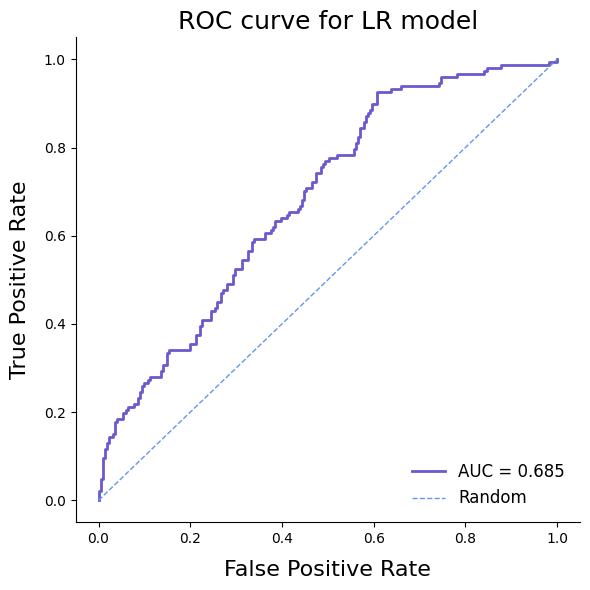

In [14]:
y_pred = model.predict(X_test)

auc = roc_auc_score(y_test, y_pred)
print(auc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 6))

ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}", color = 'slateblue')
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label ='Random', color="cornflowerblue")

ax.set_xlabel("False Positive Rate", labelpad = 10, fontsize = 16)
ax.set_ylabel("True Positive Rate", labelpad = 10, fontsize = 16)
ax.set_title("ROC curve for LR model", fontsize = 18)
ax.legend(frameon=False, loc="lower right",  fontsize = 12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [15]:
df_model = multi_lr_df.copy()
df_model.columns = df_model.columns.str.replace(" ", "_")
df_model = df_model.dropna()

X = df_model.drop(columns=["esbl_status"])
y = df_model["esbl_status"]

In [16]:
formula = "esbl_status ~ " + " + ".join(
    [f'Q("{col}")' for col in df_model.columns if col != "esbl_status"]
)

model = smf.logit(
    formula,
    data=df_model
).fit(disp=False)

print(model.summary())

                           Logit Regression Results                           
Dep. Variable:            esbl_status   No. Observations:                 1840
Model:                          Logit   Df Residuals:                     1796
Method:                           MLE   Df Model:                           43
Date:                Thu, 14 May 2026   Pseudo R-squ.:                  0.1573
Time:                        09:58:34   Log-Likelihood:                -1043.9
converged:                      False   LL-Null:                       -1238.7
Covariance Type:            nonrobust   LLR p-value:                 2.013e-57
                                                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------
Intercept                                                 -1.2784        nan        nan        nan         nan         nan

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [17]:
y_pred = model.predict(X)

auc = roc_auc_score(y, y_pred)
print(auc)

0.7580042587687953


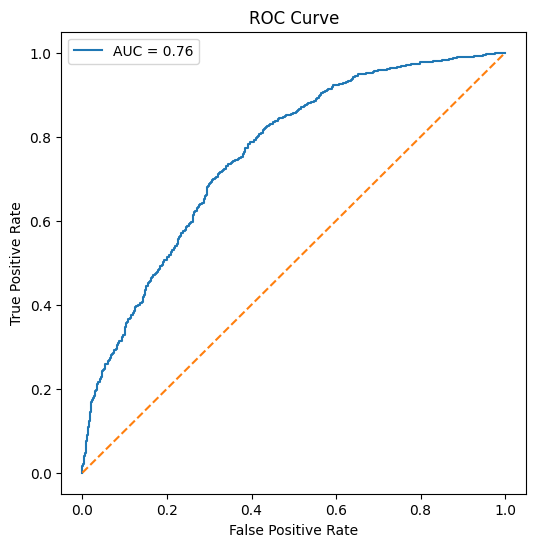

In [18]:
fpr, tpr, thresholds = roc_curve(y, y_pred)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Compute ORs from model parameters

In [19]:
params = model.params
conf = model.conf_int()

or_df = np.exp(params)
conf_or = np.exp(conf)

or_df = pd.DataFrame({
    "term": params.index,
    "odds_ratio": or_df,
    "ci_lower": conf_or[0],
    "ci_upper": conf_or[1],
    "p_value": model.pvalues
}).reset_index(drop=True)

or_df[or_df['p_value'] < 0.05]

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


,term,odds_ratio,ci_lower,ci_upper,p_value
1,"Q(""asthma"")",1.299752,1.011766,1.669708,4.021859e-02
2,"Q(""colonisation"")",4.204780,2.923939,6.046699,9.300917e-15
3,"Q(""copd"")",0.671154,0.476587,0.945154,2.243634e-02
4,"Q(""crp"")",1.002077,1.001002,1.003154,1.513050e-04
10,"Q(""ethnicity_desc_asian"")",1.689776,1.213969,2.352074,1.876465e-03
14,"Q(""ethnicity_desc_white"")",0.654268,0.508956,0.841067,9.307042e-04
20,"Q(""prophylaxis_group_broad-spectrum_beta-lactam"")",0.173635,0.048170,0.625888,7.445535e-03
23,"Q(""prophylaxis_group_clindamycin-based"")",0.327828,0.159964,0.671847,2.316389e-03
24,"Q(""prophylaxis_group_co-amoxiclav-based"")",0.591838,0.368058,0.951679,3.043904e-02
28,"Q(""site_blood"")",0.406181,0.241044,0.684454,7.143966e-04


In [20]:
import re

def split_term(term):
    if term == "Intercept":
        return "Intercept", ""
    
    # Match dummy-coded terms like Q("site__urine")[T.True]
    match = re.match(r'Q\("(.+?)"\)\[T\.True\]', term)
    if match:
        full_name = match.group(1)   # e.g. organism_bug__klebsiella_oxytoca
        
        if "__" in full_name:
            predictor, category = full_name.split("__", 1)
        else:
            predictor, category = full_name, ""
        
        return predictor, category
    
    # Continuous / binary terms like Q("age_at_admission")
    match2 = re.match(r'Q\("(.+?)"\)', term)
    if match2:
        return match2.group(1), ""
    
    return term, ""

or_df[["predictor", "category"]] = or_df["term"].apply(
    lambda x: pd.Series(split_term(x))
)

rename_dict = {
    "organism_bug": "Organism",
    "site": "Sample site",
    "tfc_group": "Surgery type",
    "prophylaxis_group": "Prophylaxis",
    "ethnicity_desc": "Ethnicity",
    "imd_decile": "Deprivation",
    "past_abx": "Prior antibiotics"
}

or_df["predictor"] = or_df["predictor"].replace(rename_dict)

In [21]:
# or_df = or_df.drop('term', axis = 1)
or_df['significant'] =  or_df['p_value'] < 0.05

In [22]:
or_df[or_df['significant'] == True]

,term,odds_ratio,ci_lower,ci_upper,p_value,predictor,category,significant
1,"Q(""asthma"")",1.299752,1.011766,1.669708,4.021859e-02,asthma,,True
2,"Q(""colonisation"")",4.204780,2.923939,6.046699,9.300917e-15,colonisation,,True
3,"Q(""copd"")",0.671154,0.476587,0.945154,2.243634e-02,copd,,True
4,"Q(""crp"")",1.002077,1.001002,1.003154,1.513050e-04,crp,,True
10,"Q(""ethnicity_desc_asian"")",1.689776,1.213969,2.352074,1.876465e-03,ethnicity_desc_asian,,True
14,"Q(""ethnicity_desc_white"")",0.654268,0.508956,0.841067,9.307042e-04,ethnicity_desc_white,,True
20,"Q(""prophylaxis_group_broad-spectrum_beta-lactam"")",0.173635,0.048170,0.625888,7.445535e-03,prophylaxis_group_broad-spectrum_beta-lactam,,True
23,"Q(""prophylaxis_group_clindamycin-based"")",0.327828,0.159964,0.671847,2.316389e-03,prophylaxis_group_clindamycin-based,,True
24,"Q(""prophylaxis_group_co-amoxiclav-based"")",0.591838,0.368058,0.951679,3.043904e-02,prophylaxis_group_co-amoxiclav-based,,True
28,"Q(""site_blood"")",0.406181,0.241044,0.684454,7.143966e-04,site_blood,,True


In [23]:
to_drop = or_df[or_df['category'] == ""].index

or_df = or_df.drop(index=to_drop)

In [24]:
or_df['predictor'].unique()

array([], dtype=object)

In [ ]:
def run_multivariable_lr(df):
    import numpy as np
    import pandas as pd
    import statsmodels.api as sm
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score

    outcome_col = "esbl_status"

    categorical_cols = [
        "ethnicity_desc",
        "organism_bug",
        "prophylaxis_group",
        "site",
        "tfc"
    ]

    reference_categories = {
        "organism_bug": "escherichia coli",
        "site": "blood",
        "ethnicity_desc": "white",
        "prophylaxis_group": "cefuroxime + metronidazole",
        "tfc": "general_surgery"
    }

    X = df.drop(columns=[outcome_col])
    y = df[outcome_col]

    if y.dtype == "object":
        y = y.map({"ESBL": 1, "non-ESBL": 0})

    X = pd.get_dummies(
        X,
        columns=[c for c in categorical_cols if c in X.columns],
        prefix_sep="__",
        drop_first=False,
        dtype=int
    )

    for col, ref in reference_categories.items():
        X = X.drop(columns=f"{col}__{ref}", errors="ignore")

    X = X.apply(pd.to_numeric, errors="coerce")

    model_df = X.copy()
    model_df[outcome_col] = y.values
    model_df = model_df.dropna()

    y = model_df[outcome_col]
    X = model_df.drop(columns=[outcome_col])

    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X, has_constant="add")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = sm.Logit(y_train, X_train).fit(disp=False)

    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)

    conf = model.conf_int()

    or_df = pd.DataFrame({
        "term": model.params.index,
        "OR": np.exp(model.params),
        "CI_lower": np.exp(conf[0]),
        "CI_upper": np.exp(conf[1]),
        "p_value": model.pvalues
    }).reset_index(drop=True)

    return {
        "model": model,
        "or_df": or_df,
        "auc": auc,
        "n": len(model_df),
        "events": int(y.sum())
    }

# Plot ORs

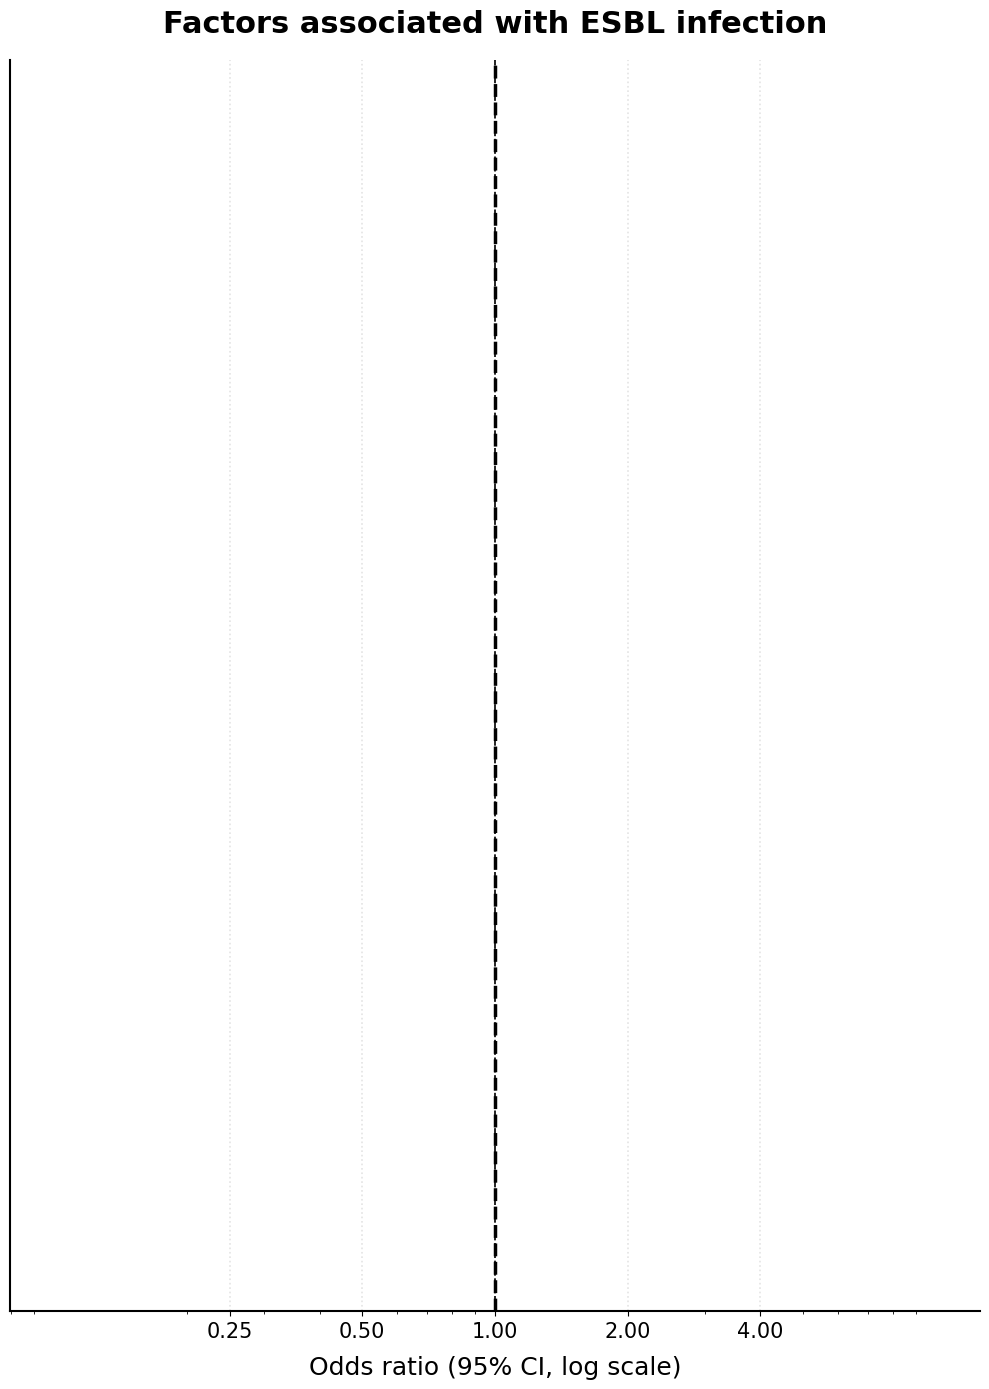

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# -----------------------------
# 1. Copy results
# -----------------------------
plot_df = or_df.copy()

plot_df = plot_df[
    np.isfinite(plot_df["odds_ratio"]) &
    np.isfinite(plot_df["ci_lower"]) &
    np.isfinite(plot_df["ci_upper"]) &
    (plot_df["ci_lower"] > 0) &
    (plot_df["ci_upper"] < 20)
].copy()

# -----------------------------
# 3. Clean labels
# -----------------------------
category_map = {

        # Ethnicity
    "asian": "Asian",
    "black": "Black",
    "white": "White",

    # organisms
    "escherichia_coli": "E. coli",
    "klebsiella_pneumoniae": "K. pneumoniae",
    "klebsiella_oxytoca": "K. oxytoca",
    "proteus_mirabilis": "P. mirabilis",

    # sites
    "blood": "Blood",
    "drain": "Drain",
    "Respiratory_pleural": "Resp./pleural",
    "wound": "Wound",
    "tips_devices": "Catheter/device",
    "Tissue/biopsy": "Tissue/biopsy",
    "Other_unknown": "Other/unknown",
    "sputum": "Sputum",
    "low_vaginal": "Low vaginal",
    "high_vaginal": "High vaginal",
    "urine": "Urine",
    "tissue/biopsy": "Tissue / biopsy",
 

    # surgical specialties
    # Surgical specialty
    "gynaecological_oncology": "Gynaecological oncology",
    "vascular": "Vascular surgery",
    "uro_nephro": "Urology / nephrology",
    "abdominal_gi": "Abdominal / GI surgery",
    "general_surgery": "General surgery",
    "ortho_plastics": "Orthopaedics / plastics",
    "Gynaecology": "Gynaecology",
    "cardiothoracic": "Cardiothoracic",
    "neuro_ent": "Neurosurgery / ENT",
    "obstetrics": "Obstetrics",
    "gynaecology" : "Gynaecology",


    # Prophylaxis
    "cephalosporin_aminoglycoside": "Cephalosporin&aminoglycoside",
    "cefuroxime": "Cefuroxime",
    "metronidazole": "Metronidazole",
    "glycopeptide_based": "Glycopeptide-based",
    "no_prophylaxis": "No prophylaxis",
    "aminoglycoside_based": "Aminoglycoside-based",
    "co-amoxiclav_(contains_penicillin)": "Co-amoxiclav",
    "clindamycin": "Clindamycin",

}

plot_df["label"] = plot_df["category"].replace(category_map)

# -----------------------------
# 4. Sort groups internally by OR
# -----------------------------
group_order = ['Organism', 'Sample site', 'Surgery type', 'Prophylaxis',
       'Ethnicity']

plot_df["group"] = pd.Categorical(plot_df["predictor"], categories=group_order, ordered=True)

plot_df = plot_df.sort_values(["group", "odds_ratio"], ascending=[True, False]).reset_index(drop=True)

# -----------------------------
# 5. Create y positions with gaps between groups
# -----------------------------
y_positions = []
current_y = 0

for grp in group_order:

    df_grp = plot_df[plot_df["group"] == grp]

    for _ in range(len(df_grp)):
        y_positions.append(current_y)
        current_y += 1

    current_y += 1  # blank line between groups

plot_df["y"] = y_positions
plot_df["significant"] = plot_df["p_value"] < 0.05

# -----------------------------
# 6. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, max(14, 0.45 * len(plot_df))))

# non-significant
df_nonsig = plot_df[~plot_df["significant"]]

ax.errorbar(
    df_nonsig["odds_ratio"],
    df_nonsig["y"],
    xerr=[
        df_nonsig["odds_ratio"] - df_nonsig["ci_lower"],
        df_nonsig["ci_upper"] - df_nonsig["odds_ratio"]
    ],
    fmt="o",
    color="0.65",
    ecolor="0.65",
    elinewidth=2,      # thicker CI lines
    capsize=3,           # bigger caps
    capthick=1,
    markersize=8,       # bigger circles
    alpha=0.9,
)

# significant
df_sig = plot_df[plot_df["significant"]]

ax.errorbar(
    df_sig["odds_ratio"],
    df_sig["y"],
    xerr=[
        df_sig["odds_ratio"] - df_sig["ci_lower"],
        df_sig["ci_upper"] - df_sig["odds_ratio"]
    ],
    fmt="o",
    color="navy",
    ecolor="navy",
    elinewidth=2,
    capsize=3,
    capthick=1,
    markersize=8,
)
# annotate OR values
for _, row in df_sig.iterrows():
    ax.text(
        row["odds_ratio"],
        row["y"] - 0.25,
        f"{row['odds_ratio']:.2f}",
        ha="center",
        va="bottom",
        fontsize=12,
        color="navy"
    )

# reference line
ax.axvline(1, color="black", linestyle="--", linewidth=1.2)

# axes


# axes
ax.set_yticks(plot_df["y"])
ax.set_yticklabels(plot_df["label"], fontsize=16)   # bigger category labels

ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4])
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())

ax.tick_params(axis='x', labelsize=15)  # bigger tick numbers

ax.set_xlabel(
    "Odds ratio (95% CI, log scale)",
    fontsize=18,
    labelpad=10
)

ax.set_title(
    "Factors associated with ESBL infection",
    fontsize=22,
    weight="bold",
    pad=20
)

# style
ax.grid(axis="x", linestyle=":", alpha=0.35, linewidth=1.2)
ax.grid(axis="y", visible=False)

# thicker reference line
ax.axvline(1, color="black", linestyle="--", linewidth=2.5)

# thicker axis lines
ax.spines["bottom"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.invert_yaxis()

plt.tight_layout()
plt.savefig("figure_poster.png", bbox_inches='tight',  pad_inches=0.1)
plt.show()

In [26]:
df_model = analysis_df.copy()
df_model.columns = df_model.columns.str.replace(" ", "_")
df_model = df_model.dropna()


X = df_model.drop(columns=["esbl_status"])
y = df_model["esbl_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Stratify by TFC and infection site 

In [ ]:
def fit_stratified_lr(
    df,
    strat_col,
    strat_value,
    outcome_col="esbl_status",
    categorical_cols=None,
    reference_categories=None,
    test_size=0.2,
    random_state=42,
    min_events=10
):
    import numpy as np
    import pandas as pd
    import statsmodels.api as sm
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score

    df = df.copy()

    if categorical_cols is None:
        categorical_cols = ["ethnicity_desc", "organism_bug", "prophylaxis_group", "site", "tfc"]

    if reference_categories is None:
        reference_categories = {
            "organism_bug": "escherichia coli",
            "site": "blood",
            "ethnicity_desc": "white",
            "prophylaxis_group": "cefuroxime + metronidazole",
            "tfc": "general_surgery"
        }

    df_stratum = df[df[strat_col] == strat_value].copy()

    y = df_stratum[outcome_col]
    if y.dtype == "object":
        y = y.map({"ESBL": 1, "non-ESBL": 0})

    X = df_stratum.drop(columns=[outcome_col, strat_col], errors="ignore")

    cat_cols = [c for c in categorical_cols if c in X.columns and c != strat_col]

    X = pd.get_dummies(
        X,
        columns=cat_cols,
        drop_first=False,
        prefix_sep="__",
        dtype=int
    )

    for col, ref in reference_categories.items():
        if col != strat_col:
            X = X.drop(columns=f"{col}__{ref}", errors="ignore")

    X = X.apply(pd.to_numeric, errors="coerce")

    model_df = X.copy()
    model_df[outcome_col] = y.values
    model_df = model_df.dropna()

    y = model_df[outcome_col]
    X = model_df.drop(columns=[outcome_col])

    X = X.loc[:, X.nunique() > 1]

    n_events = int(y.sum())
    n_nonevents = int((y == 0).sum())

    if n_events < min_events or n_nonevents < min_events:
        raise ValueError(
            f"Too few events/non-events in {strat_col}={strat_value}. "
            f"Events={n_events}, non-events={n_nonevents}."
        )

    X = sm.add_constant(X, has_constant="add")

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    model = sm.Logit(y_train, X_train).fit(disp=False)

    y_pred = model.predict(X_test)
    auc = roc_auc_score(y_test, y_pred)

    conf = model.conf_int()

    or_df = pd.DataFrame({
        "term": model.params.index,
        "OR": np.exp(model.params),
        "CI_lower": np.exp(conf[0]),
        "CI_upper": np.exp(conf[1]),
        "p_value": model.pvalues
    }).reset_index(drop=True)

    return {
        "strat_col": strat_col,
        "strat_value": strat_value,
        "n": len(model_df),
        "events": n_events,
        "non_events": n_nonevents,
        "auc_test": auc,
        "model": model,
        "or_df": or_df, 
        "X_test": X_test,
        "y_test": y_test,
        "y_pred_prob": y_pred
    }

In [ ]:
def fit_lr_by_tfc(df, tfc_value, **kwargs):
    return fit_stratified_lr(
        df=df,
        strat_col="tfc",
        strat_value=tfc_value,
        **kwargs
    )

In [ ]:
def fit_lr_by_site(df, site_value, **kwargs):
    return fit_stratified_lr(
        df=df,
        strat_col="site",
        strat_value=site_value,
        **kwargs
    )

In [ ]:
result = fit_lr_by_tfc(analysis_df, "general_surgery")
print(result["n"], result["events"], result["auc_test"])
result["or_df"].sort_values("p_value").head(20)

# Sensitivity analysis 

In [ ]:
first_episode_df = (
    analysis_df
    .sort_values(["subject_id", "sample_collection_date"])
    .drop_duplicates("subject_id", keep="first")
)

episode_counts = analysis_df["subject_id"].value_counts()

episode_counts.describe()

In [ ]:
n_patients = analysis_df["subject_id"].nunique()
n_episodes = len(analysis_df)
n_repeated_patients = (episode_counts > 1).sum()
n_repeated_episodes = analysis_df["subject_id"].duplicated().sum()

print("Episodes:", n_episodes)
print("Unique patients:", n_patients)
print("Patients with >1 episode:", n_repeated_patients)
print("Repeated episodes:", n_repeated_episodes)
print("% repeated episodes:", n_repeated_episodes / n_episodes * 100)

In [ ]:
first_episode_df = (
    analysis_df
    .sort_values(["subject_id", "sample_collection_date"])
    .drop_duplicates(subset="subject_id", keep="first")
    .copy()
)

In [ ]:
main_result = run_multivariable_lr(analysis_df)
sensitivity_result = run_multivariable_lr(first_episode_df)

model = main_result["model"]
y_test = main_result["y_test"]
y_pred_prob = main_result["y_pred_prob"]

In [ ]:
main_result["or_df"].merge(
    sensitivity_result["or_df"],
    on="term",
    suffixes=("_main", "_first_episode")
)

In [ ]:
main_result = run_multivariable_lr(analysis_df)
sensitivity_result = run_multivariable_lr(first_episode_df)

In [ ]:
comparison = main_result["or_df"].merge(
    sensitivity_result["or_df"],
    on="term",
    suffixes=("_main", "_first_episode")
)

comparison[[
    "term",
    "OR_main",
    "CI_lower_main",
    "CI_upper_main",
    "p_value_main",
    "OR_first_episode",
    "CI_lower_first_episode",
    "CI_upper_first_episode",
    "p_value_first_episode"
]]

In [ ]:
print("Main model AUC:", main_result["auc"])
print("First-episode sensitivity AUC:", sensitivity_result["auc"])

# GEE regression 

In [ ]:
def run_gee_logistic(
    df,
    outcome_col="esbl_status",
    cluster_col="subject_id",
    categorical_cols=None,
    reference_categories=None
):
    import numpy as np
    import pandas as pd
    import statsmodels.api as sm

    if categorical_cols is None:
        categorical_cols = [
            "ethnicity_desc",
            "organism_bug",
            "prophylaxis_group",
            "site",
            "tfc"
        ]

    if reference_categories is None:
        reference_categories = {
            "organism_bug": "escherichia coli",
            "site": "blood",
            "ethnicity_desc": "white",
            "prophylaxis_group": "cefuroxime + metronidazole",
            "tfc": "general_surgery"
        }

    df = df.copy()

    y = df[outcome_col]
    if y.dtype == "object":
        y = y.map({"ESBL": 1, "non-ESBL": 0})

    X = df.drop(columns=[outcome_col, cluster_col], errors="ignore")

    X = pd.get_dummies(
        X,
        columns=[c for c in categorical_cols if c in X.columns],
        prefix_sep="__",
        drop_first=False,
        dtype=int
    )

    for col, ref in reference_categories.items():
        X = X.drop(columns=f"{col}__{ref}", errors="ignore")

    X = X.apply(pd.to_numeric, errors="coerce")

    model_df = X.copy()
    model_df[outcome_col] = y.values
    model_df[cluster_col] = df[cluster_col].values
    model_df = model_df.dropna()

    y = model_df[outcome_col]
    groups = model_df[cluster_col]
    X = model_df.drop(columns=[outcome_col, cluster_col])

    # Drop zero-variance columns
    X = X.loc[:, X.nunique() > 1]

    X = sm.add_constant(X, has_constant="add")

    gee_model = sm.GEE(
        y,
        X,
        groups=groups,
        family=sm.families.Binomial(),
        cov_struct=sm.cov_struct.Exchangeable()
    )

    gee_result = gee_model.fit()

    conf = gee_result.conf_int()

    or_df = pd.DataFrame({
        "term": gee_result.params.index,
        "OR": np.exp(gee_result.params),
        "CI_lower": np.exp(conf[0]),
        "CI_upper": np.exp(conf[1]),
        "p_value": gee_result.pvalues
    }).reset_index(drop=True)

    return {
        "model": gee_result,
        "or_df": or_df,
        "n": len(model_df),
        "n_clusters": model_df[cluster_col].nunique(),
        "events": int(y.sum())
    }

In [ ]:
gee_result = run_gee_logistic(analysis_df)

gee_result["or_df"].sort_values("p_value").head(20)

In [ ]:
lr_result = run_multivariable_lr(analysis_df)

comparison = lr_result["or_df"].merge(
    gee_result["or_df"],
    on="term",
    suffixes=("_LR", "_GEE")
)

comparison[[
    "term",
    "OR_LR", "CI_lower_LR", "CI_upper_LR", "p_value_LR",
    "OR_GEE", "CI_lower_GEE", "CI_upper_GEE", "p_value_GEE"
]]

# What to report 

In [ ]:
len(raw_df)
len(analysis_df)
analysis_df["subject_id"].nunique()
analysis_df["esbl_status"].value_counts()
analysis_df["esbl_status"].value_counts(normalize=True)

In [ ]:
missing = analysis_df.isna().sum().sort_values(ascending=False)
missing_pct = analysis_df.isna().mean().sort_values(ascending=False) * 100

In [ ]:
# Model diagnostics

model.mle_retvals

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
# Confusion matrix

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

# Convert probabilities to binary predictions
threshold = 0.5

y_pred_class = (y_pred_prob >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

print(cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Classification metrics
print(classification_report(y_test, y_pred_class))

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    y_pred_prob,
    n_bins=10
)

plt.figure(figsize=(6,6))

# Perfect calibration line
plt.plot([0,1], [0,1], linestyle='--')

# Model calibration
plt.plot(prob_pred, prob_true, marker='o')

plt.xlabel("Predicted probability")
plt.ylabel("Observed proportion ESBL")
plt.title("Calibration Curve")

plt.show()